En este notebook evaluaré diferentes modelos de ML clásico a ciegas, usando el dataset original sin refinar para poder ver qué modelos pueden ser más prometedores para el trabajo.

~Santi

In [4]:
## importamos todos los modelos basicos de clasificacion: KNN, SVM, Decision Tree, Random Forest, Logistic Regression, Naive Bayes

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
import pandas as pd

In [10]:
data_basic = pd.read_csv('../data/processed/data_basic.csv')

test_max_abs = pd.read_csv('../data/processed/data_testmax_abs.csv')
test_min_max = pd.read_csv('../data/processed/data_testmin_max.csv')
test_robust = pd.read_csv('../data/processed/data_testrobust.csv')
test_standard = pd.read_csv('../data/processed/data_teststandard.csv')

train_max_abs = pd.read_csv('../data/processed/data_trainmax_abs.csv')
train_min_max = pd.read_csv('../data/processed/data_trainmin_max.csv')
train_robust = pd.read_csv('../data/processed/data_trainrobust.csv')
train_standard = pd.read_csv('../data/processed/data_trainstandard.csv')

In [15]:
X_max_abs, y_max_abs = train_max_abs.drop('Variable de Salida', axis=1), train_max_abs['Variable de Salida']
X_min_max, y_min_max = train_min_max.drop('Variable de Salida', axis=1), train_min_max['Variable de Salida']
X_robust, y_robust = train_robust.drop('Variable de Salida', axis=1), train_robust['Variable de Salida']
X_standard, y_standard = train_standard.drop('Variable de Salida', axis=1), train_standard['Variable de Salida']

X_test_max_abs, y_test_max_abs = test_max_abs.drop('Variable de Salida', axis=1), test_max_abs['Variable de Salida']
X_test_min_max, y_test_min_max = test_min_max.drop('Variable de Salida', axis=1), test_min_max['Variable de Salida']
X_test_robust, y_test_robust = test_robust.drop('Variable de Salida', axis=1), test_robust['Variable de Salida']
X_test_standard, y_test_standard = test_standard.drop('Variable de Salida', axis=1), test_standard['Variable de Salida']

KNN Max Abs
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       163
           1       0.00      0.00      0.00        43

    accuracy                           0.79       206
   macro avg       0.40      0.50      0.44       206
weighted avg       0.63      0.79      0.70       206

Mejor combinación de hiperparámetros para KNN Max Abs: {'n_neighbors': 21, 'weights': 'uniform'}
[0.680428677014043, 0.7697560975609756, 0.7849482631189949, 0.7898004434589802, 0.7928381374722839, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226, 0.7922246858832226]


c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


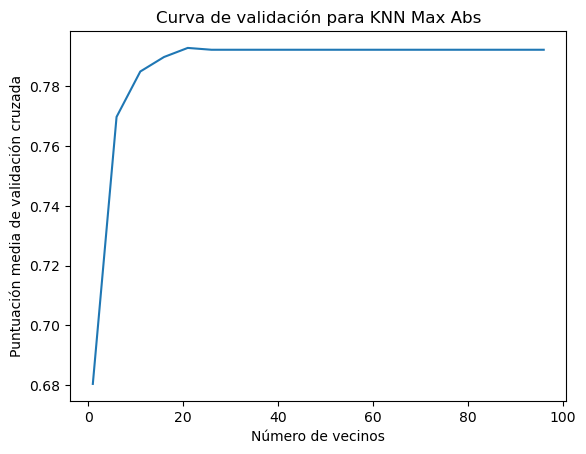

In [44]:
import matplotlib.pyplot as plt 

## KNN
knn_max_abs = KNeighborsClassifier()
n_neighbors = list(range(1, 100, 5))
param_grid_knn = {'n_neighbors': n_neighbors, 'weights': ['uniform', 'distance']}
grid_knn_max_abs = GridSearchCV(knn_max_abs, param_grid_knn, cv=5)
grid_knn_max_abs.fit(X_max_abs.values, y_max_abs.values)
y_pred_knn_max_abs = grid_knn_max_abs.predict(X_test_max_abs.values)
print("KNN Max Abs")
print(classification_report(y_test_max_abs, y_pred_knn_max_abs))

## mostrar mejor combinacion de hiperparametros para KNN
print("Mejor combinación de hiperparámetros para KNN Max Abs:", grid_knn_max_abs.best_params_)
## plotear codo para KNN
mean_scores = [grid_knn_max_abs.cv_results_['mean_test_score'][i:i+2].mean() for i in range(0, len(grid_knn_max_abs.cv_results_['mean_test_score']), 2)]
print(mean_scores)
plt.plot(n_neighbors, mean_scores)
plt.xlabel('Número de vecinos')
plt.ylabel('Puntuación media de validación cruzada')
plt.title('Curva de validación para KNN Max Abs')
plt.show()

In [23]:
## SVM
svm_max_abs = SVC()
svm_max_abs.fit(X_max_abs, y_max_abs)
y_pred_svm_max_abs = svm_max_abs.predict(X_test_max_abs.values)
print("SVM Max Abs")
print(classification_report(y_test_max_abs, y_pred_svm_max_abs))

SVM Max Abs
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       163
           1       0.00      0.00      0.00        43

    accuracy                           0.79       206
   macro avg       0.40      0.50      0.44       206
weighted avg       0.63      0.79      0.70       206



c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Santiago\miniconda3\envs\AANS\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined